In [ ]:
'''Для задания использовала датасет из промежут аттестации'''

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

uploaded = files.upload()

Saving customer_churn_features.csv to customer_churn_features.csv


In [3]:
df = pd.read_csv("customer_churn_features.csv")

print("Размер датасета:", df.shape)
print("\nСтолбцы:")
print(df.columns.tolist())

display(df.head())

Размер датасета: (10000, 22)

Столбцы:
['customer_id', 'age', 'gender', 'registration_date', 'annual_income', 'account_count', 'active_account_count', 'card_count', 'active_card_count', 'transaction_count', 'total_transaction_amount', 'avg_transaction_amount', 'card_purchase_count', 'atm_withdrawal_count', 'transfer_out_count', 'utility_payment_count', 'transfer_count', 'loan_count', 'total_loan_amount', 'avg_interest_rate', 'last_transaction_date', 'churn']


,customer_id,age,gender,registration_date,annual_income,account_count,active_account_count,card_count,active_card_count,transaction_count,...,card_purchase_count,atm_withdrawal_count,transfer_out_count,utility_payment_count,transfer_count,loan_count,total_loan_amount,avg_interest_rate,last_transaction_date,churn
0,1,34,M,2025-07-12,455276.04,1,1,1,1,266,...,249,5,0,0,0,0,0.0,0.0,2026-01-27,0
1,2,54,M,2025-03-22,1945830.96,2,2,1,1,465,...,434,9,0,4,0,0,0.0,0.0,2026-01-26,0
2,3,18,F,2025-10-01,315794.16,1,1,1,1,155,...,144,2,1,1,1,0,0.0,0.0,2026-01-27,0
3,4,18,F,2025-11-22,647645.88,2,2,1,1,76,...,70,2,0,2,0,0,0.0,0.0,2026-01-25,0
4,5,49,M,2025-09-30,1061109.84,2,2,0,0,165,...,153,2,0,3,0,0,0.0,0.0,2026-01-27,0


In [ ]:
'''
Целевая переменная  `churn`: значение 0 означает отсутствие оттока, а значение 1  наличие оттока.
Эту переменную будем использовать для обучения модели классификации.
'''

In [4]:
'''Проверка данных'''
print("Пропуски:")
print(df.isnull().sum().sum())

print("\nДубликаты:")
print(df.duplicated().sum())

print("\nРаспределение целевой переменной:")
print(df["churn"].value_counts())

print("\nДоля оттока:")
print(df["churn"].value_counts(normalize=True).round(3))

Пропуски:
0

Дубликаты:
0

Распределение целевой переменной:
churn
0    9303
1     697
Name: count, dtype: int64

Доля оттока:
churn
0    0.93
1    0.07
Name: proportion, dtype: float64


In [ ]:
'''Проверка показала, что в данных нет пропусков и дубликатов.
Из 10 000 клиентов у 9303 отток отсутствует, а у 697 он есть.
Классы распределены неравномерно, поэтому для оценки модели нужно использовать несколько метрик качества.'''

In [ ]:
'''
На этом этапе подготовим данные для обучения модели KNN.
Целевой переменной будет `churn`, а остальные подходящие признаки будут использоваться
для классификации клиентов. Данные разделим на обучающую и тестовую выборки, а числовые признаки масштабируем.
'''

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# Выбираем признаки и целевую переменную
X = df.drop(columns=[
    "churn", "customer_id",
    "registration_date", "last_transaction_date"
])
y = df["churn"]

# Разделяем данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Подготовка числовых и категориальных признаков
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["gender"])
])

# Создаём и обучаем модель KNN
model = Pipeline([
    ("preprocessor", preprocessor),
    ("knn", KNeighborsClassifier(n_neighbors=7))
])

model.fit(X_train, y_train)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)
print("Модель KNN обучена.")

Размер обучающей выборки: (8000, 18)
Размер тестовой выборки: (2000, 18)
Модель KNN обучена.


In [ ]:
'''Дальше для оценки качества модели построим ROC-кривую и Precision-Recall кривую.
Они помогут оценить способность модели выявлять клиентов с оттоком при разных порогах классификации.
'''

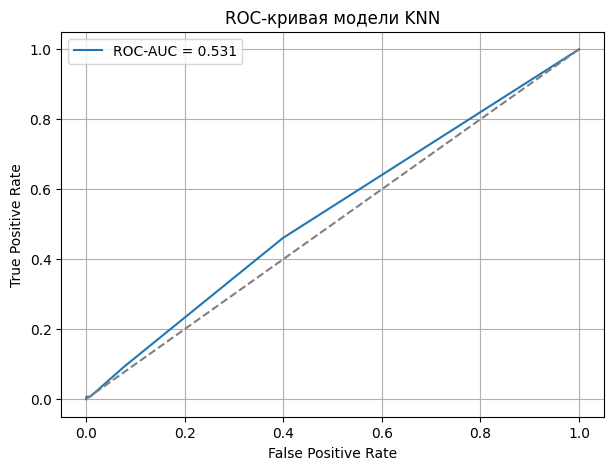

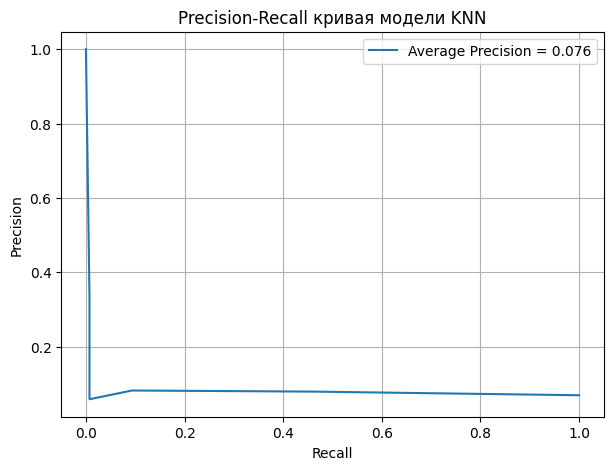

ROC-AUC: 0.531
Average Precision: 0.076


In [6]:
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve,
    average_precision_score
)

# Вероятности оттока на тестовой выборке
y_probs = model.predict_proba(X_test)[:, 1]

# ROC-кривая
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая модели KNN")
plt.legend()
plt.grid()
plt.show()

# Precision-Recall кривая
precision, recall, _ = precision_recall_curve(y_test, y_probs)
ap = average_precision_score(y_test, y_probs)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"Average Precision = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall кривая модели KNN")
plt.legend()
plt.grid()
plt.show()

print("ROC-AUC:", round(roc_auc, 3))
print("Average Precision:", round(ap, 3))

In [ ]:
'''По ROC-кривой и Precision-Recall кривой видно, что качество модели KNN невысокое.
Значение ROC-AUC равно 0,531, а Average Precision - 0,076. Модель слабо выявляет клиентов с оттоком,
поэтому далее проверим качество классификации при разных порогах вероятности.
'''

In [ ]:
'''Обычно модель относит объект к классу 1, если вероятность составляет не менее 0,5.
Но при несбалансированных данных такой порог может быть не самым подходящим.
Поэтому проверим разные значения порога и выбрали то, при котором F1-score максимален.
Затем рассчитаем основные метрики качества и матрицу ошибок.
 Важно учитывать, что порог подбирался на тестовой выборке, поэтому результаты не являются полностью независимой оценкой модели.
'''

In [7]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)

thresholds = np.arange(0.05, 0.96, 0.01)

scores = [
    f1_score(y_test, (y_probs >= t).astype(int), zero_division=0)
    for t in thresholds
]

best_threshold = thresholds[np.argmax(scores)]
y_pred = (y_probs >= best_threshold).astype(int)

print("Выбранный порог:", round(best_threshold, 2))
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred, zero_division=0), 3))
print("Recall:", round(recall_score(y_test, y_pred, zero_division=0), 3))
print("F1-score:", round(f1_score(y_test, y_pred, zero_division=0), 3))

print("\nМатрица ошибок:")
print(confusion_matrix(y_test, y_pred))

print("\nОтчёт по классам:")
print(classification_report(y_test, y_pred, zero_division=0))

Выбранный порог: 0.05
Accuracy: 0.591
Precision: 0.079
Recall: 0.46
F1-score: 0.135

Матрица ошибок:
[[1118  743]
 [  75   64]]

Отчёт по классам:
              precision    recall  f1-score   support

           0       0.94      0.60      0.73      1861
           1       0.08      0.46      0.14       139

    accuracy                           0.59      2000
   macro avg       0.51      0.53      0.43      2000
weighted avg       0.88      0.59      0.69      2000



In [ ]:
'''Модель с порогом 0,05 смогла найти 64 клиента из 139, которые ушли.
Но при этом она часто ошибалась и отмечала клиентов, которые не ушли. Полнота составила 46%, а точность — около 8%.

В целом модель работает не очень хорошо: она находит часть клиентов с оттоком,
но часто ошибается. Чтобы улучшить результат, можно попробовать другие модели классификации.
'''

In [ ]:
'''Построим матрицу ошибок в виде тепловой карты, чтобы наглядно увидеть, сколько клиентов модель определила правильно и сколько раз ошиблась.
'''

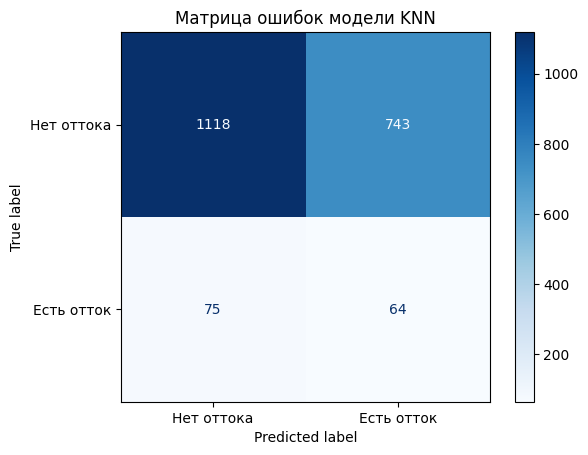

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Нет оттока", "Есть отток"],
    cmap="Blues"
)

plt.title("Матрица ошибок модели KNN")
plt.show()

In [ ]:
'''Для определения клиентов с оттоком был выбран порог 0,05. Это значит,
что модель относит клиента к группе с оттоком, если вероятность оттока составляет 5% или выше.
 Такой порог помог найти больше клиентов, которые ушли, но при этом модель стала чаще ошибаться. Порог был выбран по показателю F1-score.
'''

In [ ]:
'''В ходе работы была обучена модель KNN, которая определяет клиентов с оттоком.
Модель смогла найти часть таких клиентов, но часто ошибалась. Например,
среди клиентов, которых она отметила как ушедших, только около 8% действительно имели отток.
Поэтому качество модели оказалось низким. В дальнейшем можно попробовать другие модели, чтобы получить более точные результаты.
'''